# EDA Meter Profile Raw

전처리 이전(raw에 가까운) 단일 계량기 상세 EDA입니다. 기본 대상은 `H1.Z16`이며, `fetch_joined_data()` 기준으로 weather join과 숫자형 변환까지만 적용합니다.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path('/home/playdata2/final_pj/energy-platform')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from config.meter_metadata import get_metadata
from scripts.preprocess_h1z16 import fetch_joined_data

METER_URN = 'H1.Z16'
OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'eda_raw' / METER_URN.replace('.', '_')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

metadata = get_metadata(METER_URN)
raw_df = fetch_joined_data(METER_URN).sort_values('ts').reset_index(drop=True)
raw_df['hour'] = raw_df['ts'].dt.hour
raw_df['month'] = raw_df['ts'].dt.month
raw_df['is_weekend'] = raw_df['ts'].dt.dayofweek.isin([5, 6]).astype(int)
target_col = metadata['anomaly_target']
metadata

{'meter_type': 'electric',
 'energy_type': 'consumption',
 'thermal_mode': None,
 'anomaly_target': 'P',
 'group_name': 'cooling_central',
 'redundant_pair': None,
 'description': 'CM1'}

## 1. 기초 통계 (Raw)

In [2]:
print('rows:', len(raw_df))
print('start_ts:', raw_df['ts'].min())
print('end_ts:', raw_df['ts'].max())
display(raw_df[[c for c in [target_col, 'W', 'PF', 'Ta', 'Igm'] if c in raw_df.columns]].describe())
display(raw_df[[c for c in [target_col, 'W', 'PF', 'Ta', 'Igm'] if c in raw_df.columns]].isnull().sum())

if target_col in raw_df.columns:
    print('negative target count:', int((raw_df[target_col] < 0).sum()))
if 'W' in raw_df.columns:
    print('negative W count:', int((raw_df['W'] < 0).sum()))

rows: 52585
start_ts: 2018-01-01 00:00:00+00:00
end_ts: 2024-01-01 00:00:00+00:00


,P,W,PF,Ta,Igm
count,52583.000000,52585.000000,52583.000000,51349.000000,51349.000000
mean,1073.468053,23050.238142,0.987090,12.404151,133.644633
std,2899.232530,15128.593067,0.030923,7.968016,215.031755
min,1.813054,1286.010000,0.198800,-11.200232,0.000000
25%,435.439250,7035.499952,0.994000,6.244085,0.000000
50%,440.270167,22827.948772,0.994000,11.774729,5.361705
75%,445.217441,37839.977043,0.994000,18.123194,188.806556
max,38167.579833,57772.425328,0.998000,39.349571,990.356136


P         2
W         0
PF        2
Ta     1236
Igm    1236
dtype: int64

negative target count: 0
negative W count: 0


## 2. 시계열 시각화 (Raw)

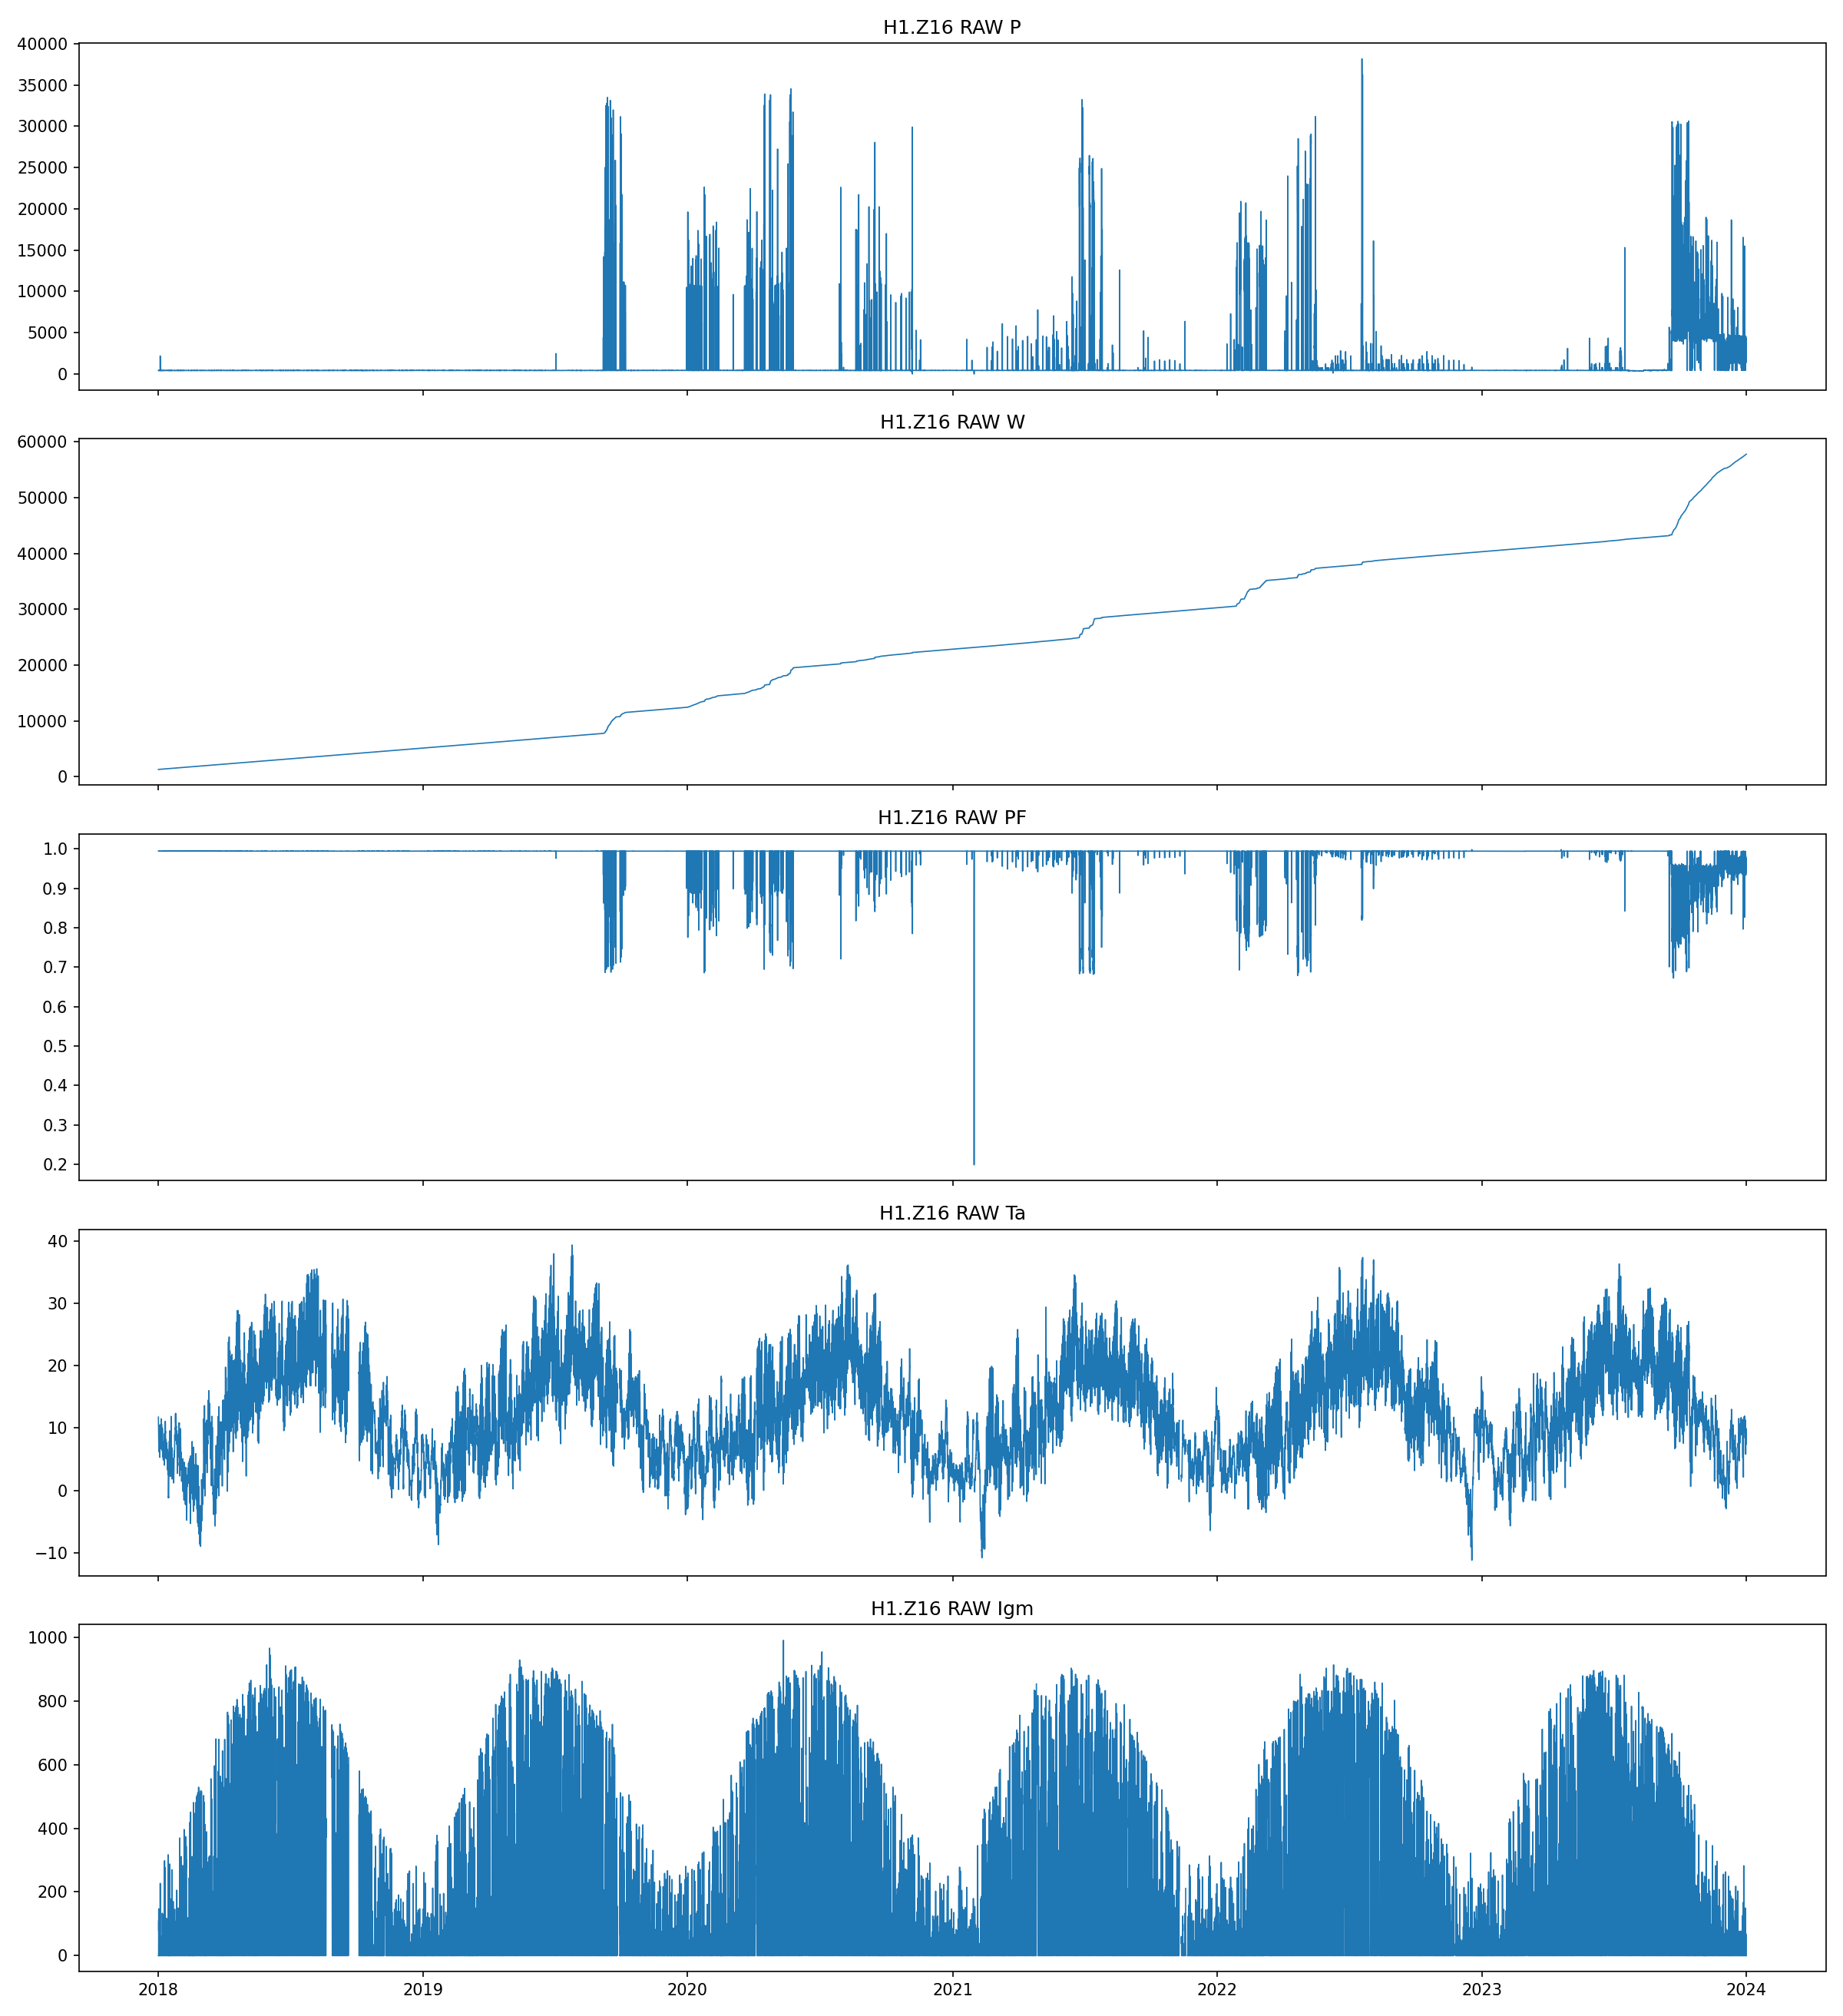

In [3]:
cols = [c for c in [target_col, 'W', 'PF', 'Ta', 'Igm'] if c in raw_df.columns]
fig, axes = plt.subplots(len(cols), 1, figsize=(16, 3.5 * len(cols)), sharex=True)
if len(cols) == 1:
    axes = [axes]
for ax, col in zip(axes, cols):
    ax.plot(raw_df['ts'], raw_df[col], linewidth=0.8)
    ax.set_title(f'{METER_URN} RAW {col}')
plt.tight_layout()
plot_path = OUTPUT_DIR / f'{METER_URN.replace('.', '_')}_raw_timeseries.png'
plt.savefig(plot_path, dpi=150)
plt.close(fig)
display(Image(filename=str(plot_path)))

## 3. 그룹 집계 (Raw)

,hour,P
0,0,836.940124
1,1,800.435664
2,2,836.615289
3,3,792.258242
4,4,796.732015


,month,P
0,1,875.535616
1,2,1121.928140
2,3,799.150164
3,4,993.995067
4,5,1023.616965


,is_weekend,P
0,0,1161.638164
1,1,853.028103


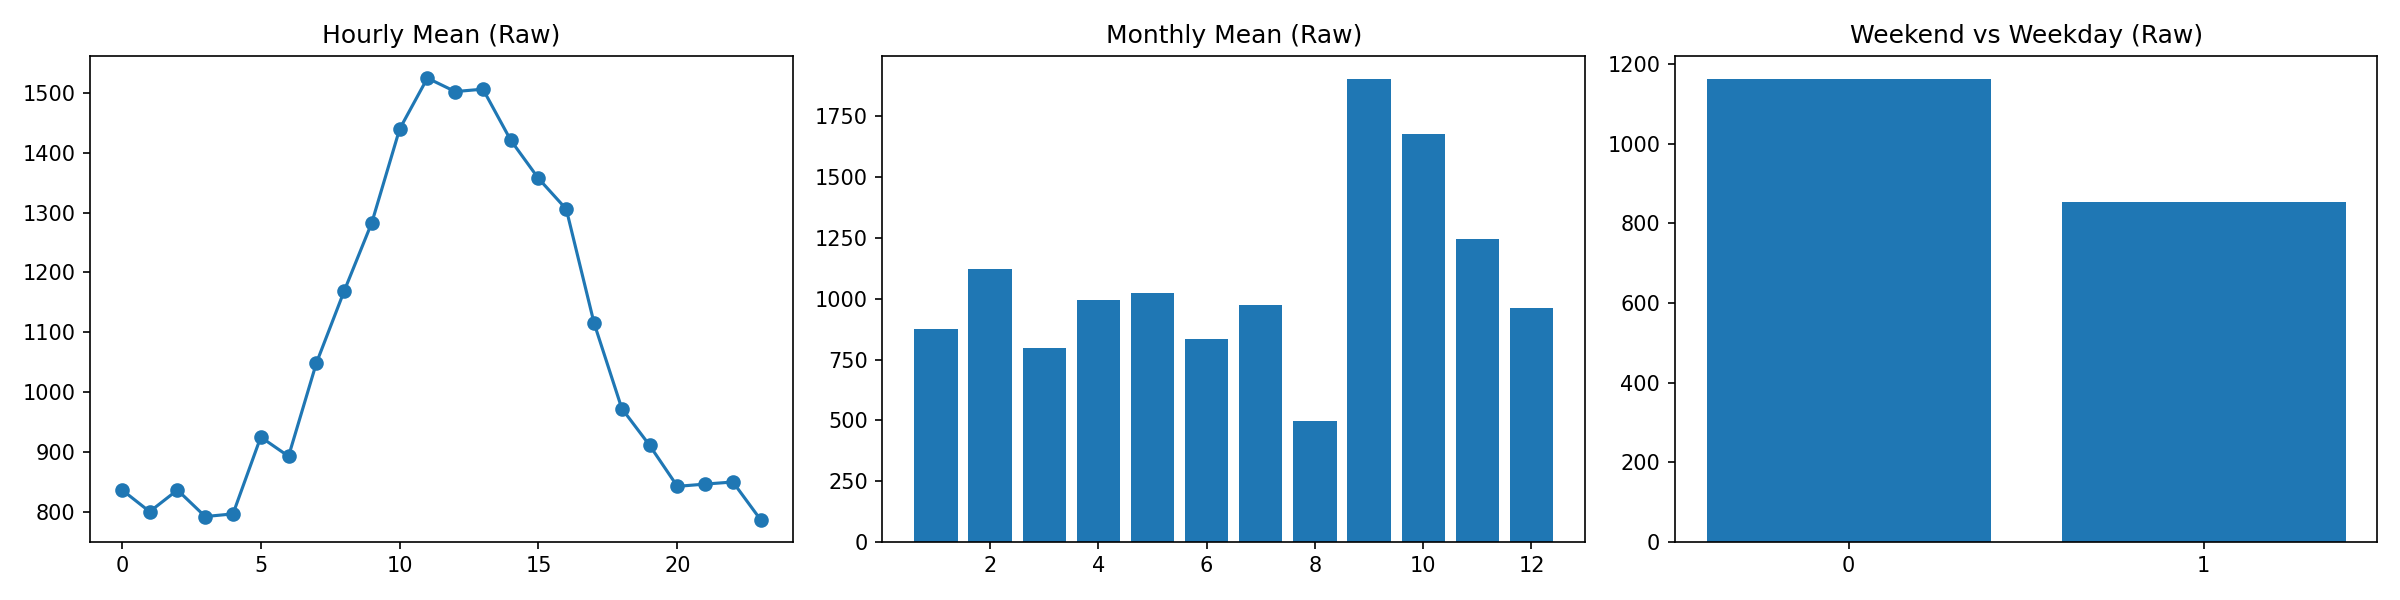

In [4]:
hourly = raw_df.groupby('hour')[target_col].mean().reset_index()
monthly = raw_df.groupby('month')[target_col].mean().reset_index()
weekend = raw_df.groupby('is_weekend')[target_col].mean().reset_index()
display(hourly.head())
display(monthly.head())
display(weekend)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(hourly['hour'], hourly[target_col], marker='o')
axes[0].set_title('Hourly Mean (Raw)')
axes[1].bar(monthly['month'], monthly[target_col])
axes[1].set_title('Monthly Mean (Raw)')
axes[2].bar(weekend['is_weekend'].astype(str), weekend[target_col])
axes[2].set_title('Weekend vs Weekday (Raw)')
plt.tight_layout()
plot_path = OUTPUT_DIR / f'{METER_URN.replace('.', '_')}_raw_profiles.png'
plt.savefig(plot_path, dpi=150)
plt.close(fig)
display(Image(filename=str(plot_path)))

## 4. 상관분석 / 데이터 품질 (Raw)

,P,PF,I1,I2,I3,P1,P2,P3,Ta,Igm
P,1.000000,-0.937275,0.997762,0.997682,0.995678,0.999971,0.999973,0.997551,0.061663,0.060331
PF,-0.937275,1.000000,-0.954847,-0.954899,-0.957270,-0.936277,-0.937044,-0.941219,-0.036296,-0.035866
I1,0.997762,-0.954847,1.000000,0.999271,0.998944,0.997540,0.997643,0.997750,0.058336,0.057067
I2,0.997682,-0.954899,0.999271,1.000000,0.998546,0.997457,0.997613,0.997218,0.057860,0.056897
I3,0.995678,-0.957270,0.998944,0.998546,1.000000,0.995285,0.995443,0.998436,0.058540,0.057230
P1,0.999971,-0.936277,0.997540,0.997457,0.995285,1.000000,0.999956,0.997297,0.061827,0.060313
P2,0.999973,-0.937044,0.997643,0.997613,0.995443,0.999956,1.000000,0.997309,0.061198,0.060089
P3,0.997551,-0.941219,0.997750,0.997218,0.998436,0.997297,0.997309,1.000000,0.062570,0.060844
Ta,0.061663,-0.036296,0.058336,0.057860,0.058540,0.061827,0.061198,0.062570,1.000000,0.514770
Igm,0.060331,-0.035866,0.057067,0.056897,0.057230,0.060313,0.060089,0.060844,0.514770,1.000000


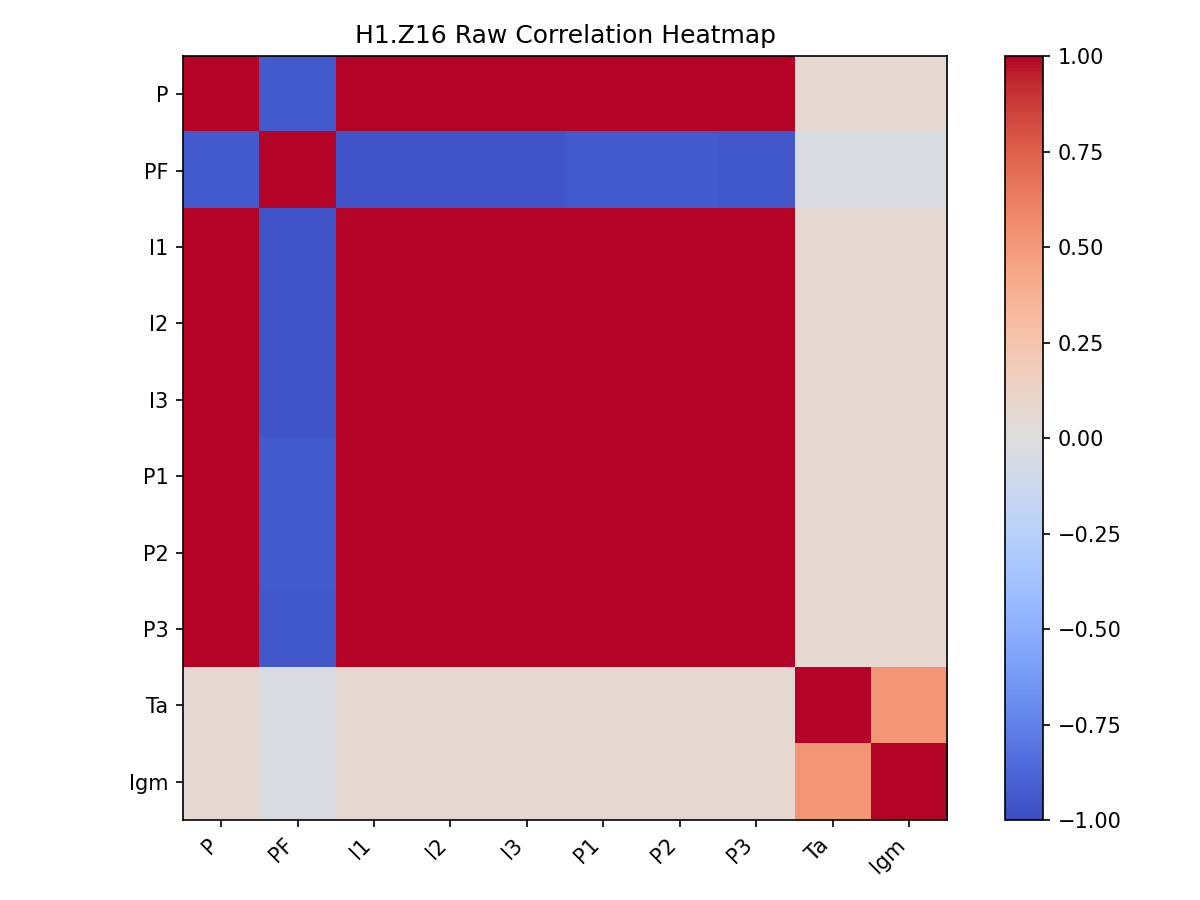

,null_count,null_ratio
Ta,1236,0.023505
Igm,1236,0.023505
W_out,690,0.013122
P3,62,0.001179
PF3,62,0.001179
I3,62,0.001179
P1,2,0.000038
PF2,2,0.000038
PF1,2,0.000038
P,2,0.000038


In [5]:
corr_cols = [c for c in [target_col, 'PF', 'I1', 'I2', 'I3', 'P1', 'P2', 'P3', 'Ta', 'Igm'] if c in raw_df.columns and raw_df[c].notna().any()]
corr = raw_df[corr_cols].corr(numeric_only=True)
display(corr)

plt.figure(figsize=(8, 6))
plt.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)
plt.xticks(range(len(corr_cols)), corr_cols, rotation=45, ha='right')
plt.yticks(range(len(corr_cols)), corr_cols)
plt.colorbar()
plt.title(f'{METER_URN} Raw Correlation Heatmap')
plt.tight_layout()
plot_path = OUTPUT_DIR / f'{METER_URN.replace('.', '_')}_raw_corr.png'
plt.savefig(plot_path, dpi=150)
plt.close()
display(Image(filename=str(plot_path)))

quality_df = pd.DataFrame({
    'null_count': raw_df.isnull().sum(),
    'null_ratio': raw_df.isnull().mean(),
}).sort_values('null_ratio', ascending=False)
display(quality_df.head(15))
quality_df.to_csv(OUTPUT_DIR / f'{METER_URN.replace('.', '_')}_raw_quality.csv', encoding='utf-8-sig')